 # Importing requiered modules 


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data

In [3]:
df = pd.read_csv("bama_ml_dataset.csv")
df.head()

,brand,model,year,mileage_km,city,price,price_type,transmission,body_color,inside_color,body_status,engine_liter,link
0,پژو,پژو، 2008,1397,89000,تهران / سهروردی,3.200000e+09,lumpsum,اتوماتیک,سفید,مشکی,یک لکه رنگ,1.6,https://bama.ir/car/detail-duxhngsg-peugeot-20...
1,نیسان,نیسان، ترا,1404,0,تهران / اقدسیه,9.800000e+09,lumpsum,اتوماتیک,سفید,-,بدون رنگ,2.0,https://bama.ir/car/detail-qekwouyx-nissan-ter...
2,میتسوبیشی,میتسوبیشی، اوتلندر,2018,61000,پیرانشهر,8.500000e+09,lumpsum,اتوماتیک,سفید,مشکی,بدون رنگ,2.4,https://bama.ir/car/detail-fhu4wa57-mitsubishi...
3,تویوتا,تویوتا، راوفور,2025,0,تهران / عباس‌آباد,2.000000e+10,lumpsum,اتوماتیک,سرمه ای,مشکی,بدون رنگ,2.5,https://bama.ir/car/detail-d6vgnl4o-toyota-rav...
4,لوکانو,لوکانو، L7,1405,0,تهران / جنت آباد,8.300000e+09,installment,اتوماتیک,مشکی,مشکی,بدون رنگ,1.6,https://bama.ir/car/detail-dahj2yzu-lucano-l7-...


# Data Cleaning

In [4]:
df = df[df["price"] > 0]
df = df[df["price"] < 30000000000]   # کمتر از 30 میلیارد
df= df[df['engine_liter'] < 10]
df = df.drop_duplicates(subset="link")
df = df.dropna(subset=["year", "engine_liter"])
df.size

237770

## Feature Engineering

### Converting years to the lunar calendar

In [5]:
def shamsi_to_gregorian(year):

    year = int(year)

    if year < 1500:
        return year + 621

    return year
df["year"] = df["year"].apply(shamsi_to_gregorian)


### Targeting x & y

In [6]:
x = df[['year', 'mileage_km','engine_liter','brand', 'transmission', 'body_status','body_color']]
y=df['price']
cat_features = ['brand', 'transmission', 'body_status','body_color']

## Correlation Matrix

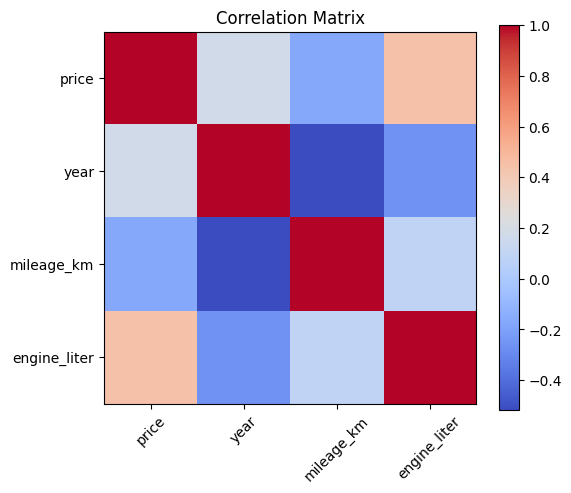

In [7]:
import matplotlib.pyplot as plt

corr = df[["price", "year", "mileage_km", "engine_liter"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

## Average Price by Brand

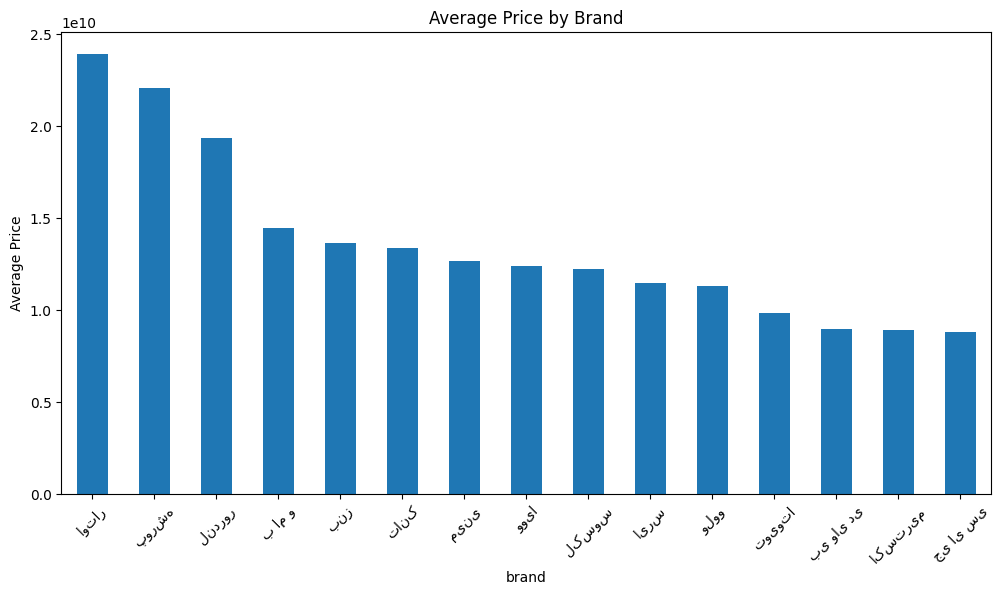

In [22]:
top = df.groupby("brand")["price"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

top.plot(kind="bar")

plt.title("Average Price by Brand")

plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

### Spliting data to test and train 

In [8]:
msk = np.random.rand(len(df)) < 0.85
train_x = x[msk]
test_x = x[~msk]
train_y = y[msk]
test_y = y[~msk]

# 1st Model : CatBoostRegressor

In [9]:
model = CatBoostRegressor(cat_features=cat_features, verbose=0, random_state=42)
model.fit(train_x, train_y)

y_pred = model.predict(test_x)
r2 = r2_score(test_y, y_pred)
mae = mean_absolute_error(test_y, y_pred)

print(f'R²: {r2:.2f}')
print(f'MAE: {mae:.2f}')
print("MAE:", mean_absolute_error(test_y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(test_y, y_pred)))

R²: 0.84
MAE: 776636400.77
MAE: 776636400.7739551
RMSE: 1566126956.82268


### One-Hot Encoding for Machine Learning Models

Most machine learning models (e.g., Linear Regression, Decision Tree, Random Forest, XGBoost, and LightGBM) cannot process categorical text features directly. Therefore, categorical columns (`brand`, `transmission`, `body_status`, and `body_color`) are converted into numerical binary features using **One-Hot Encoding**.

After encoding, the dataset is split into training (80%) and testing (20%) sets for model evaluation.

In [10]:
x_other = pd.get_dummies(
    x,
    columns=[
        "brand",
        "transmission",
        "body_status",
        "body_color"
    ],
    drop_first=True
)

from sklearn.model_selection import train_test_split

train_x2, test_x2, train_y2, test_y2 = train_test_split(
    x_other,
    y,
    test_size=0.2,
    random_state=42
)

# 2nd model : LinearRegression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()

model.fit(train_x2, train_y2)

pred = model.predict(test_x2)

print("Linear Regression")
print("R2  :", r2_score(test_y2, pred))
print("MAE :", mean_absolute_error(test_y2, pred))
print("RMSE:", np.sqrt(mean_squared_error(test_y2, pred)))

Linear Regression
R2  : 0.7452014790849772
MAE : 1172712742.2444
RMSE: 2078392525.8214831


# 3rd model : DecisionTreeRegressor

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model = DecisionTreeRegressor(
    random_state=42
)

model.fit(train_x2, train_y2)

pred = model.predict(test_x2)

print("Decision Tree")
print("R2  :", r2_score(test_y2, pred))
print("MAE :", mean_absolute_error(test_y2, pred))
print("RMSE:", np.sqrt(mean_squared_error(test_y2, pred)))

Decision Tree
R2  : 0.8089493761801826
MAE : 775039642.7864885
RMSE: 1799713401.7255278


# 4th model : GradientBoostingRegressor

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model = GradientBoostingRegressor(
    random_state=42
)

model.fit(train_x2, train_y2)

pred = model.predict(test_x2)

print("Gradient Boosting")
print("R2  :", r2_score(test_y2, pred))
print("MAE :", mean_absolute_error(test_y2, pred))
print("RMSE:", np.sqrt(mean_squared_error(test_y2, pred)))

Gradient Boosting
R2  : 0.7947981133165026
MAE : 1073858120.1829479
RMSE: 1865175900.4027333


# 5th model : RandomForestRegressor

In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1)

model.fit(train_x2, train_y2)

pred = model.predict(test_x2)
print("R2  :", r2_score(test_y2, pred))
print("MAE :", mean_absolute_error(test_y2, pred))
print("RMSE:", np.sqrt(mean_squared_error(test_y2, pred)))

R2  : 0.8646166262824406
MAE : 677636909.2629193
RMSE: 1514997048.7975247


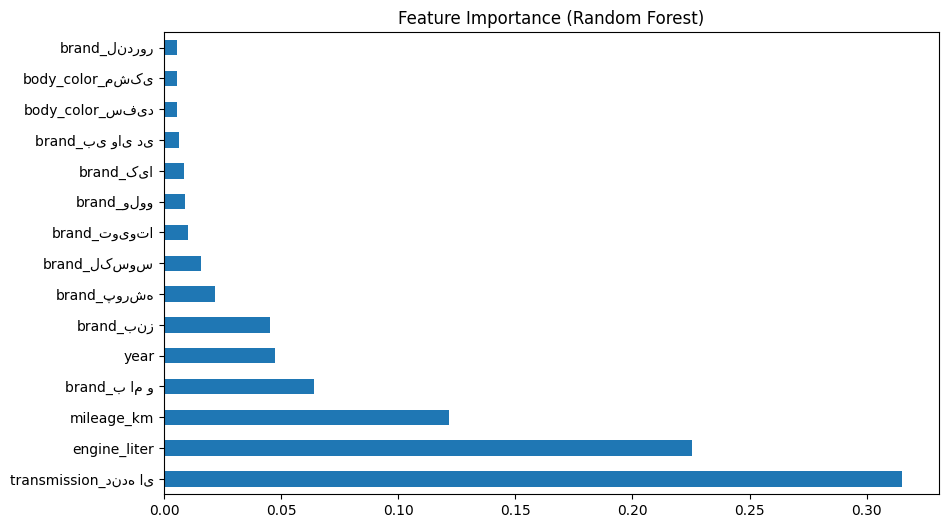

In [17]:
importance = model.feature_importances_

features = train_x2.columns

imp = pd.Series(
    importance,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

imp.head(15).plot(kind="barh")

plt.title("Feature Importance (Random Forest)")

plt.show()

## Actual vs Predicted

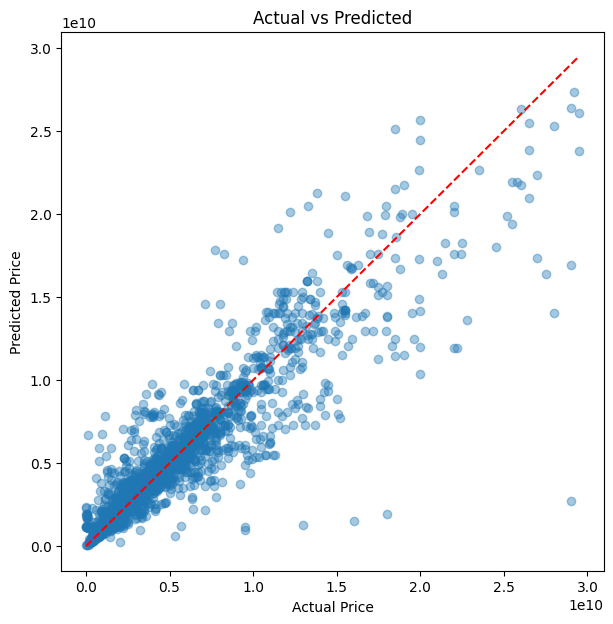

In [18]:
plt.figure(figsize=(7,7))

plt.scatter(
    test_y2,
    pred,
    alpha=0.4
)

plt.plot(
    [test_y2.min(), test_y2.max()],
    [test_y2.min(), test_y2.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [19]:
df.to_csv(
    "bama_ml_dataset_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Clean dataset saved.")

✅ Clean dataset saved.


## Model Performance Comparison

Four regression models were trained and evaluated using the R² score to compare their prediction performance.

| Model | R² Score |
|--------|:--------:|
| Linear Regression | 0.73 |
| Decision Tree | 0.80 |
| Gradient Boosting | 0.80 |
| CatBoost | 0.84 |
| Random Forest | **0.86** |

### Conclusion

Among the evaluated models, **Random Forest** achieved the highest performance with an **R² score of 0.86**, indicating the best predictive accuracy on the test dataset. **CatBoost** ranked second with an **R² score of 0.84**, while **Decision Tree** and **Gradient Boosting** achieved similar performance (**0.80**). **Linear Regression** produced the lowest accuracy (**0.73**), suggesting that the relationship between the input features and vehicle prices is non-linear.